## Generate figures for simulated data

## Import packages

In [ ]:
import numpy as np
from scipy import io

import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt

from plotly.subplots import make_subplots

from sca.models import SCA, WeightedPCA
from sca.util import get_sample_weights, get_accuracy

from sklearn.decomposition import FactorAnalysis
from sklearn.decomposition import FastICA
from sklearn.decomposition import SparsePCA

from nimfa import Nmf

## Load Data

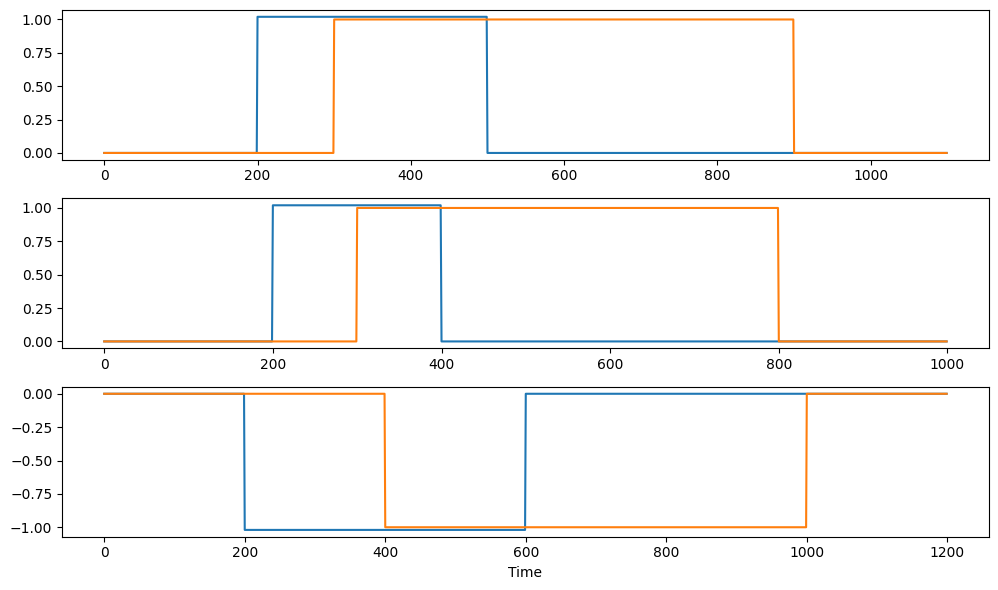

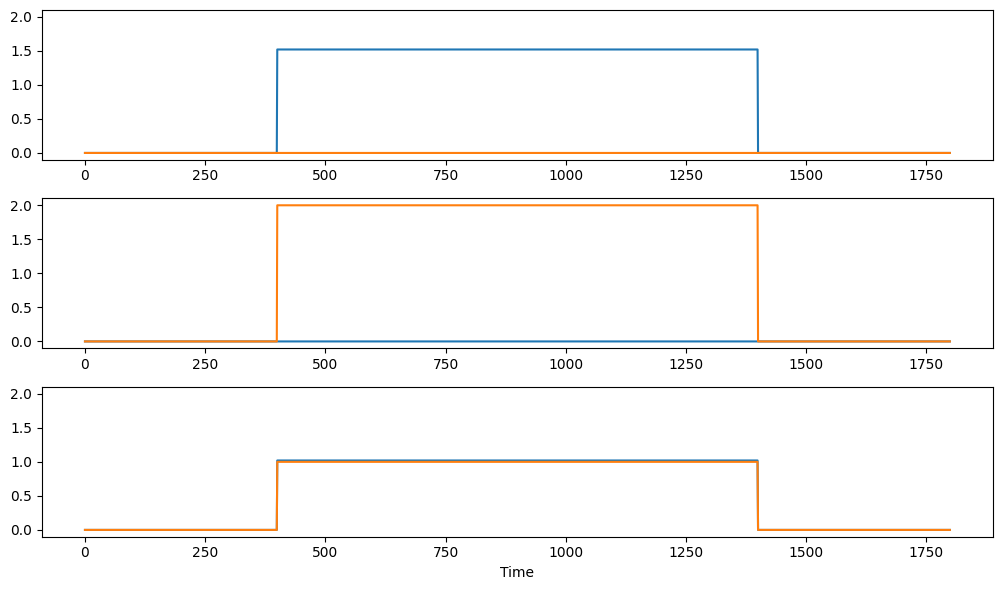

In [2]:
# Parameters
n_pad = 200  # Padding before and after
conditions = [
    (100, 200, 400, 1.0 + 0.02, 1.0),      # Condition 1
    (100, 100, 400, 1.0 + 0.02, 1.0),      # Condition 2
    (200, 200, 400, -1.0 - 0.02, -1.0),    # Condition 3
]

# Helper function to generate each condition block
def create_condition(f1_dur, cooccur_dur, f2_dur, f1_val, f2_val):
    f1_only = np.column_stack([np.full(f1_dur, f1_val), np.zeros(f1_dur)])
    cooccur = np.column_stack([np.full(cooccur_dur, f1_val), np.full(cooccur_dur, f2_val)])
    f2_only = np.column_stack([np.zeros(f2_dur), np.full(f2_dur, f2_val)])
    return np.vstack([f1_only, cooccur, f2_only])

# Build all condition segments with padding
all_segments_sim1 = []
for (f1_dur, cooccur_dur, f2_dur, f1_val, f2_val) in conditions:
    cond = create_condition(f1_dur, cooccur_dur, f2_dur, f1_val, f2_val)
    pad_before = np.zeros((n_pad, 2))
    pad_after = np.zeros((n_pad, 2))
    segment = np.vstack([pad_before, cond, pad_after])
    all_segments_sim1.append(segment)

# Plot conditions in separate subplots (stacked vertically)
fig, axes = plt.subplots(len(all_segments_sim1), 1, figsize=(10, 6), sharex=False)

for i, segment in enumerate(all_segments_sim1):
    time = np.arange(segment.shape[0])
    axes[i].plot(time, segment[:, 0], label="Factor 1",)
    axes[i].plot(time, segment[:, 1], label="Factor 2")


axes[-1].set_xlabel("Time")
plt.tight_layout()
# plt.savefig('sim1_ground_truth.pdf')
plt.show()


# Parameters
n_samples = 1000              # Samples per condition
n_pad = 400                   # Padding before and after

# Define condition blocks
cond1 = np.column_stack([np.ones(n_samples)*1.5+0.02, np.zeros(n_samples)])     # [1, 0]
cond2 = np.column_stack([np.zeros(n_samples), np.ones(n_samples)*2])            # [0, 1]
cond3 = np.column_stack([np.ones(n_samples)+0.02, np.ones(n_samples)])          # [1, 1]

conditions = [cond1, cond2, cond3]

# Build each condition segment with padding
all_segments_sim2 = []
for cond in conditions:
    pad_before = np.zeros((n_pad, 2))
    pad_after = np.zeros((n_pad, 2))
    segment = np.vstack([pad_before, cond, pad_after])
    all_segments_sim2.append(segment)

# Plot conditions in separate subplots (stacked vertically)
fig, axes = plt.subplots(len(all_segments_sim2), 1, figsize=(10, 6), sharex=False)

for i, segment in enumerate(all_segments_sim2):
    time = np.arange(segment.shape[0])
    axes[i].set_ylim(-0.1, 2.1)
    axes[i].plot(time, segment[:, 0], label="Factor 1")
    axes[i].plot(time, segment[:, 1], label="Factor 2")

axes[-1].set_xlabel("Time")
plt.tight_layout()
# plt.savefig('sim2_ground_truth.pdf')
plt.show()

In [3]:
import numpy.random as npr
from scipy.linalg import orth

Z_sim1 = np.vstack(all_segments_sim1)
np.random.seed(0) #To get the same simulated data

N_neurons=50 #Number of neurons
R_sim=2 #Number of dimensions in lowD representations

#Orthogonal matrix that projects low dimensional space to full neural space
V_tmp=orth(npr.randn(R_sim,N_neurons).T).T 

V_tmp_pos=npr.rand(R_sim,N_neurons)

#Create high-dimensional neural activity    
b=npr.randn(N_neurons) #Offset of neurons
X0_sim1=Z_sim1@V_tmp[:R_sim,:]+b #Project into high-dimensional space and add offset
noise_level = 0.1
X0_sim1=X0_sim1+noise_level*npr.randn(X0_sim1.shape[0],X0_sim1.shape[1]) #Add noise
X0_sim1_pos = Z_sim1@V_tmp_pos[:R_sim,:]+npr.rand(N_neurons)+noise_level*npr.randn(X0_sim1.shape[0],X0_sim1.shape[1])

Z_sim2 = np.vstack(all_segments_sim2)

#Orthogonal matrix that projects low dimensional space to full neural space
V_tmp=orth(npr.randn(R_sim,N_neurons).T).T 
V_tmp_pos=npr.rand(R_sim,N_neurons)

#Create high-dimensional neural activity    
b=npr.randn(N_neurons) #Offset of neurons
X0_sim2=Z_sim2@V_tmp[:R_sim,:]+b #Project into high-dimensional space and add offset
noise_level = 0.1
X0_sim2=X0_sim2+noise_level*npr.randn(X0_sim2.shape[0],X0_sim2.shape[1]) #Add noise
X0_sim2_pos = Z_sim2@V_tmp_pos[:R_sim,:]+npr.rand(N_neurons)+noise_level*npr.randn(X0_sim2.shape[0],X0_sim2.shape[1])


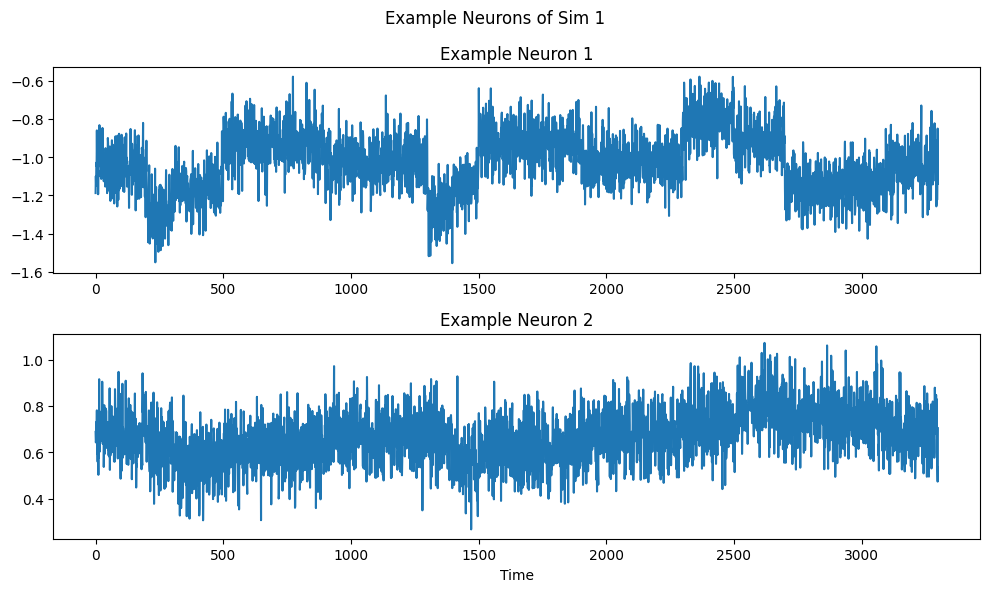

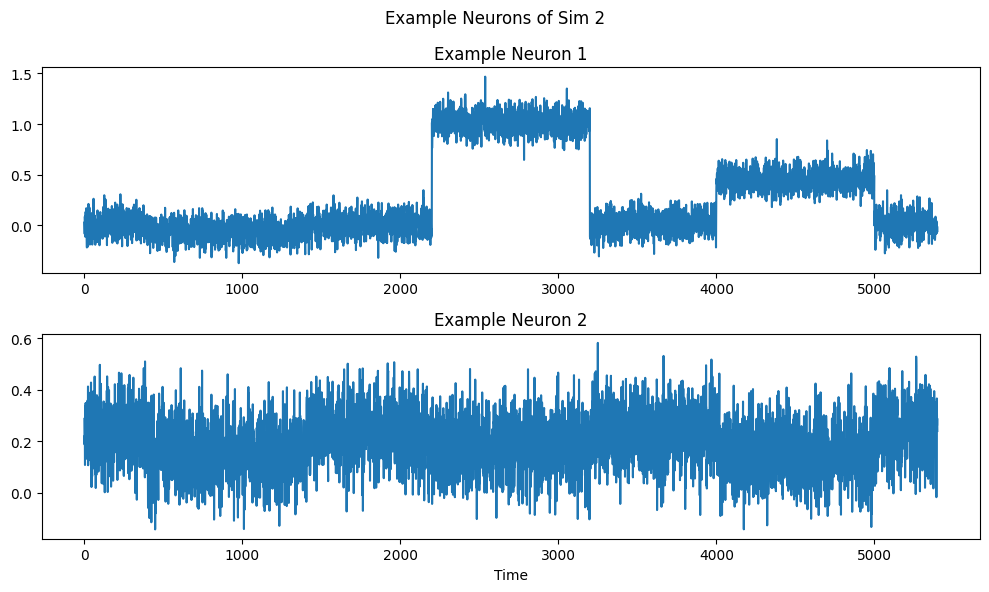

In [25]:
# Plot example neurons of simulated data
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)   
fig.suptitle("Example Neurons of Sim 1")
for i in range(2):
    time = np.arange(X0_sim1.shape[0])
    axes[i].plot(time, X0_sim1[:, i], label="Sim 1")
    axes[i].set_title(f"Example Neuron {i+1}")
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)   
fig.suptitle("Example Neurons of Sim 2")
for i in range(2):
    time = np.arange(X0_sim2.shape[0])
    axes[i].plot(time, X0_sim2[:, i], label="Sim 2")
    axes[i].set_title(f"Example Neuron {i+1}")
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Preprocess data

In [4]:
X_sim1=np.copy(X0_sim1-np.mean(X0_sim1,axis=0)[None,:])
X_sim2=np.copy(X0_sim2-np.mean(X0_sim2,axis=0)[None,:])
R_est = 2

X_sim1_pos=np.copy(X0_sim1_pos)
X_sim1_pos[X_sim1_pos<0]=0

X_sim2_pos=np.copy(X0_sim2_pos)
X_sim2_pos[X_sim2_pos<0]=0

sample_weights_sim1=np.ones([X_sim1.shape[0],1]) #Weight equally
sample_weights_sim2=np.ones([X_sim2.shape[0],1]) #Weight equally

# Fit methods

In [5]:
fit_data = X_sim1
fit_data_pos = X_sim1_pos
sample_weights = sample_weights_sim1

# fit SCA
sca=SCA(n_components=R_est, n_epochs=5000)
# sca=SCA(n_components=R_est,lam_sparse=lam_sparse, n_epochs=5000)
sca_latent_sim1=sca.fit_transform(X=fit_data, sample_weight=sample_weights)

##### PCA
pca = WeightedPCA(n_components = R_est)
pca_latent_sim1 = pca.fit_transform(fit_data,sample_weight=sample_weights)

##### PCA+Varimax
pca_var = WeightedPCA(n_components = R_est, rotate=True)
pca_var_latent_sim1 = pca_var.fit_transform(fit_data,sample_weight=sample_weights)

#### Factor Analysis
fa = FactorAnalysis(n_components= R_est)
fa_latent_sim1 = fa.fit_transform(fit_data)

# #### NMF
nmf = Nmf(fit_data_pos,rank=R_est)
nmf_fit = nmf()
nmf_latent_sim1=np.array(nmf_fit.basis())


#### ICA
# ica = FastICA(R_est)
ica = FastICA(R_est,whiten='unit-variance')
ica_latent_sim1=ica.fit_transform(fit_data)

#### Sparse PCA
spca = SparsePCA(n_components= R_est)
spca_latent_sim1 = spca.fit_transform(fit_data)

Using lam_sparse=  0.04812322905762327
Using lam_orthog=  7874.2319649011715
Using device cpu
1732.331
3272.5286


100%|██████████| 5000/5000 [00:11<00:00, 430.30it/s]


In [6]:
fit_data = X_sim2
fit_data_pos = X_sim2_pos
sample_weights = sample_weights_sim2

# fit SCA
sca=SCA(n_components=R_est, n_epochs=5000)
sca_latent_sim2=sca.fit_transform(X=fit_data, sample_weight=sample_weights)

##### PCA
pca = WeightedPCA(n_components = R_est)
pca_latent_sim2 = pca.fit_transform(fit_data,sample_weight=sample_weights)

##### PCA+Varimax
pca_var = WeightedPCA(n_components = R_est, rotate=True)
pca_var_latent_sim2 = pca_var.fit_transform(fit_data,sample_weight=sample_weights)

#### Factor Analysis
fa = FactorAnalysis(n_components= R_est)
fa_latent_sim2 = fa.fit_transform(fit_data)

# #### NMF
nmf = Nmf(fit_data_pos,rank=R_est)
nmf_fit = nmf()
nmf_latent_sim2=np.array(nmf_fit.basis())


#### ICA
# ica = FastICA(R_est)
ica = FastICA(R_est,whiten='unit-variance')
ica_latent_sim2=ica.fit_transform(fit_data)

#### Sparse PCA
spca = SparsePCA(n_components= R_est)
spca_latent_sim2 = spca.fit_transform(fit_data)

Using lam_sparse=  0.03909890916479951
Using lam_orthog=  12940.279129103814
Using device cpu
2846.8616
6619.253


100%|██████████| 5000/5000 [00:15<00:00, 324.26it/s]


### Calculate correlation

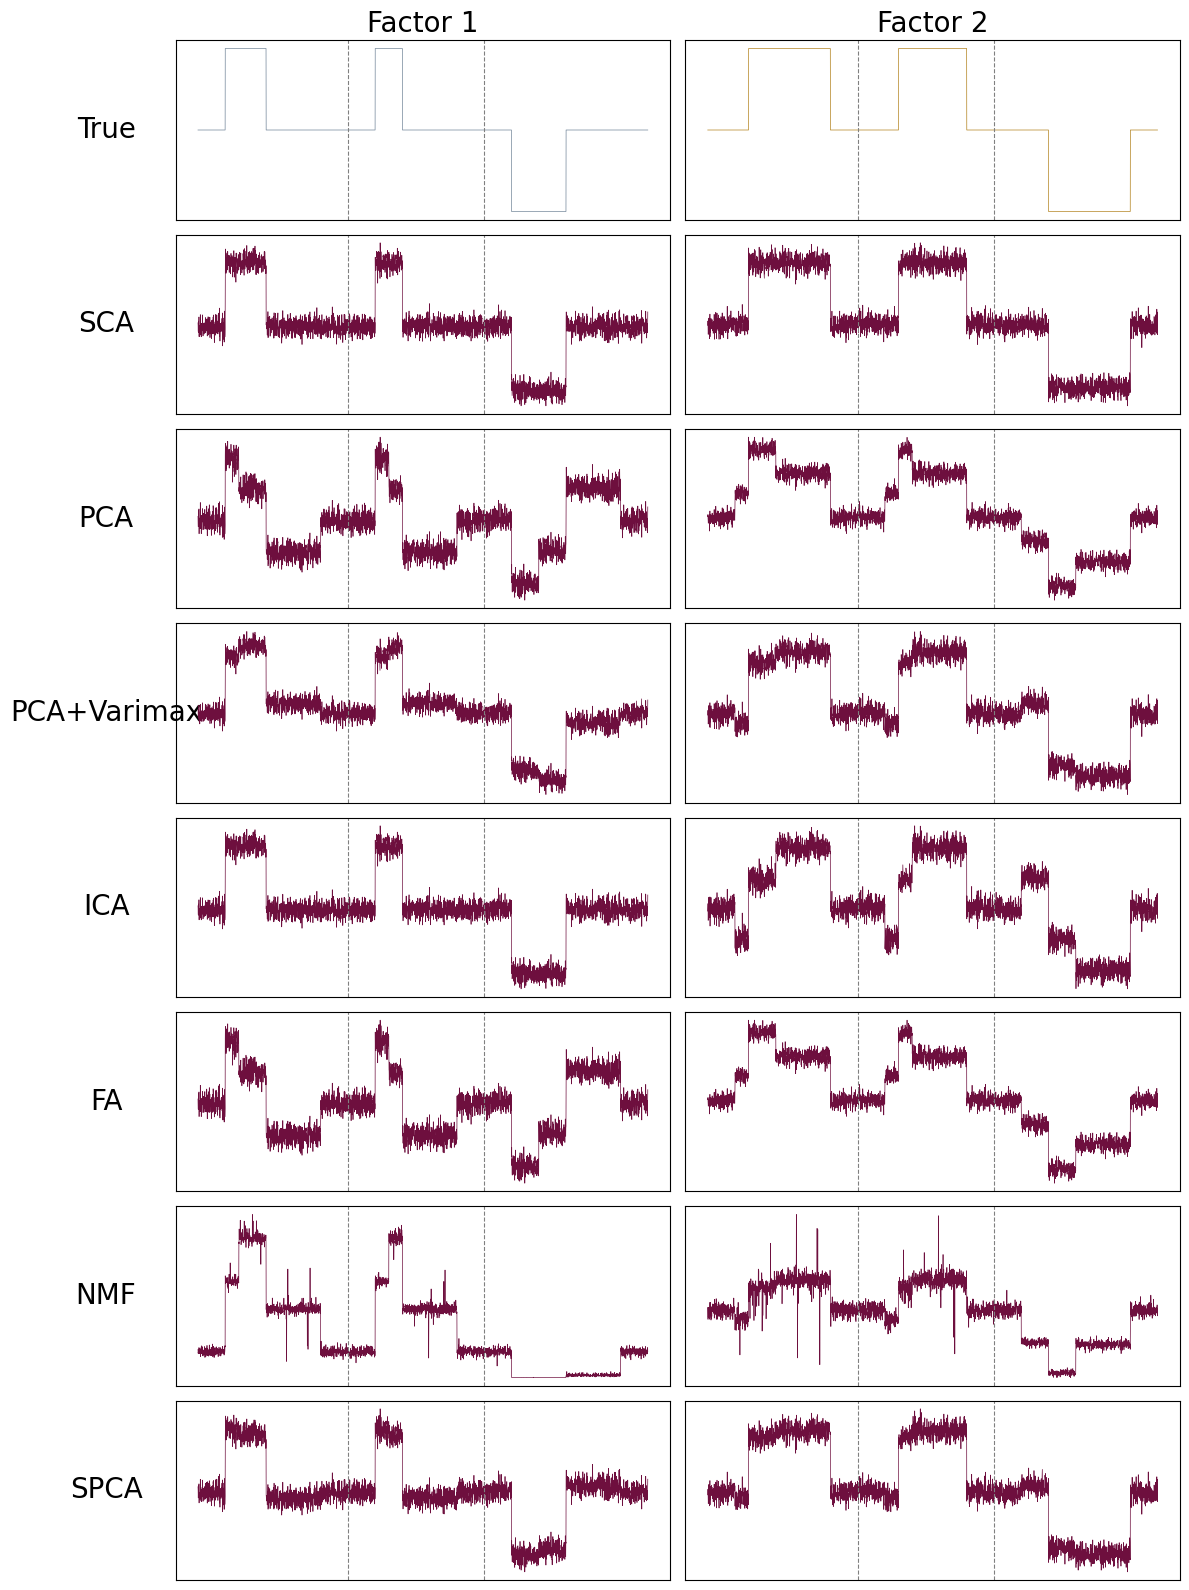

In [21]:
from scipy.optimize import linear_sum_assignment

Z_extra = Z_sim1

methods = [
    ("SCA", sca_latent_sim1),
    ("PCA", pca_latent_sim1),
    ("PCA+Varimax", pca_var_latent_sim1),
    ("ICA", ica_latent_sim1),
    ("FA", fa_latent_sim1),
    ("NMF", nmf_latent_sim1),
    ("SPCA", spca_latent_sim1),
]


aligned_methods = [("True", Z_extra)]  # first one is ground truth, no need to align
metrics = {"True": 1.0}  # perfect correlation baseline

# --- Align each method with ground truth ---
for name, latent in methods:
    corr = np.corrcoef(latent.T, Z_extra.T)[:R_est, R_est:]  # correlations (latent vs true)
    
    # Hungarian algorithm: maximize absolute correlation
    cost = -np.abs(corr)  # minimize negative correlation = maximize abs(corr)
    row_ind, col_ind = linear_sum_assignment(cost)
    
    aligned = np.zeros_like(latent)
    for r, c in zip(row_ind, col_ind):
        sign = np.sign(corr[r, c])
        aligned[:, c] = latent[:, r] * sign
        
    aligned_methods.append((name, aligned))

    abs_corrs = [np.corrcoef(aligned[:, j], Z_extra[:, j])[0, 1] for j in range(R_est)]
    score = np.mean(np.abs(abs_corrs))
    metrics[name] = score

num_methods = len(aligned_methods)

colors_true = ["#728599", "#b2821d"]
color_recon = "#6e0f3e"

num_methods = len(aligned_methods)
# Transposed layout: methods on rows, factors on columns
plt.figure(figsize=(6 * R_est, 2 * num_methods))

for i, (title, data) in enumerate(aligned_methods):   # loop over methods (rows)
    for j in range(R_est):                            # loop over factors (cols)
        ax = plt.subplot(num_methods, R_est, i * R_est + j + 1)
        
        # Choose color
        if title.startswith("True"):
            color = colors_true[j]
        else:
            color = color_recon
        
        ax.plot(data[:, j], color=color,linewidth=0.5)
        
        # Add dotted lines splitting y-axis in thirds
        y1 = 1100   
        y2 = 2100
        ax.axvline(y1, color="gray", linestyle="--", linewidth=0.8)
        ax.axvline(y2, color="gray", linestyle="--", linewidth=0.8)
        
        # Remove ticks and labels
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        # Titles for factor columns (only on top row)
        if i == 0:
            ax.set_title(f"Factor {j+1}",fontsize=20)
        
        # Method names only at the start of each row (leftmost panel)
        if j == 0:
            ax.set_ylabel(title, rotation=0, labelpad=50, va="center",fontsize=20)

plt.tight_layout()

# plt.savefig('sim1_all_methods.pdf')
plt.show()
metrics_sim1 = metrics

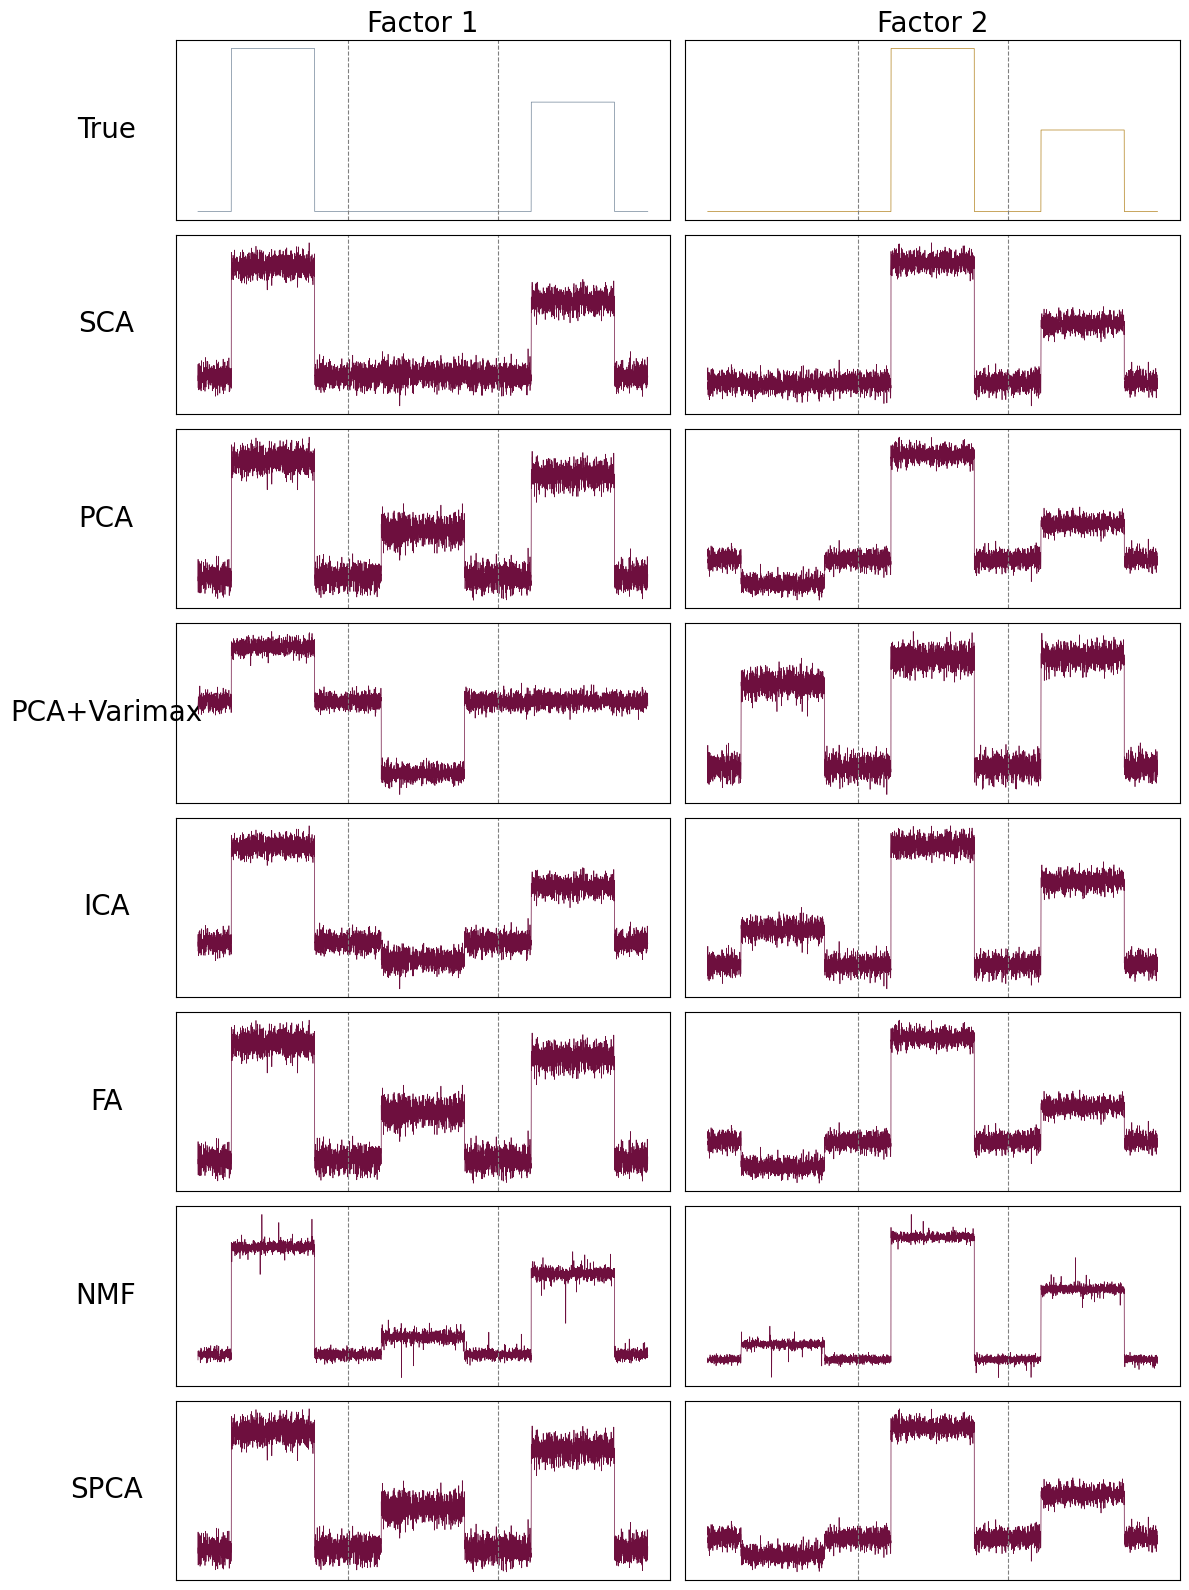

In [8]:
from scipy.optimize import linear_sum_assignment

Z_extra = Z_sim2

methods = [
    ("SCA", sca_latent_sim2),
    ("PCA", pca_latent_sim2),
    ("PCA+Varimax", pca_var_latent_sim2),
    ("ICA", ica_latent_sim2),
    ("FA", fa_latent_sim2),
    ("NMF", nmf_latent_sim2),
    ("SPCA", spca_latent_sim2),
]


aligned_methods = [("True", Z_extra)]  # first one is ground truth, no need to align
metrics = {"True": 1.0}  # perfect correlation baseline

# --- Align each method with ground truth ---
for name, latent in methods:
    corr = np.corrcoef(latent.T, Z_extra.T)[:R_est, R_est:]  # correlations (latent vs true)
    
    # Hungarian algorithm: maximize absolute correlation
    cost = -np.abs(corr)  # minimize negative correlation = maximize abs(corr)
    row_ind, col_ind = linear_sum_assignment(cost)
    
    aligned = np.zeros_like(latent)
    for r, c in zip(row_ind, col_ind):
        sign = np.sign(corr[r, c])
        aligned[:, c] = latent[:, r] * sign
        
    aligned_methods.append((name, aligned))

    abs_corrs = [np.corrcoef(aligned[:, j], Z_extra[:, j])[0, 1] for j in range(R_est)]
    score = np.mean(np.abs(abs_corrs))
    metrics[name] = score

num_methods = len(aligned_methods)

colors_true = ["#728599", "#b2821d"]
color_recon = "#6e0f3e"

num_methods = len(aligned_methods)
# Transposed layout: methods on rows, factors on columns
plt.figure(figsize=(6 * R_est, 2 * num_methods))

for i, (title, data) in enumerate(aligned_methods):   # loop over methods (rows)
    for j in range(R_est):                            # loop over factors (cols)
        ax = plt.subplot(num_methods, R_est, i * R_est + j + 1)
        
        # Choose color
        if title.startswith("True"):
            color = colors_true[j]
        else:
            color = color_recon
        
        ax.plot(data[:, j], color=color,linewidth=0.5)
        
        # Add dotted lines splitting y-axis in thirds
        y1 = 1800
        y2 = 3600
        ax.axvline(y1, color="gray", linestyle="--", linewidth=0.8)
        ax.axvline(y2, color="gray", linestyle="--", linewidth=0.8)
        
        # Remove ticks and labels
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        # Titles for factor columns (only on top row)
        if i == 0:
            ax.set_title(f"Factor {j+1}",fontsize=20)
        
        # Method names only at the start of each row (leftmost panel)
        if j == 0:
            ax.set_ylabel(title, rotation=0, labelpad=50, va="center",fontsize=20)

plt.tight_layout()

# plt.savefig('sim2_all_methods.pdf')
plt.show()
metrics_sim2 = metrics

## Plot

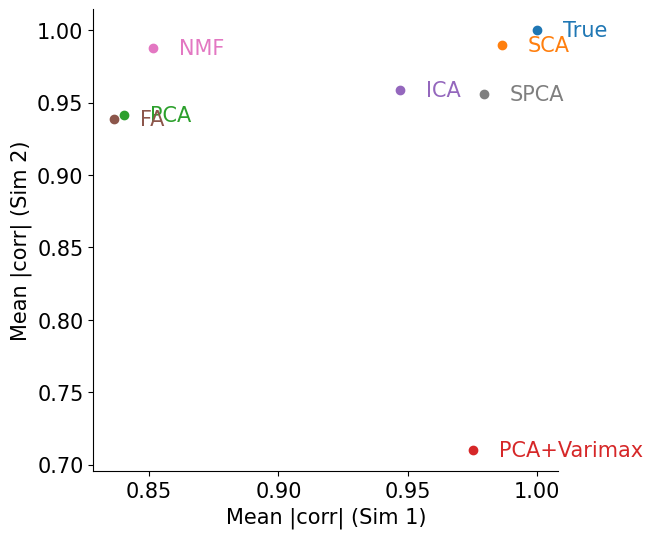

In [10]:
# Common methods between sim1 and sim2
common_methods = [m for m in metrics_sim1.keys() if m in metrics_sim2]

x = [metrics_sim1[m] for m in common_methods]
y = [metrics_sim2[m] for m in common_methods]

# Use a color cycle (different color for each method)
colors = plt.cm.tab10.colors  # 10 distinct colors
color_map = {m: colors[i % len(colors)] for i, m in enumerate(common_methods)}

plt.figure(figsize=(6, 6))

for xi, yi, name in zip(x, y, common_methods):
    plt.scatter(xi, yi, color=color_map[name], label=name)
    plt.text(xi + 0.01, yi, name, fontsize=15, color=color_map[name],va="center")

# Axis limits (first quadrant zoomed in)
# plt.xlim(0.79, 1.01)
# plt.ylim(0.79, 1.01)

plt.xlabel("Mean |corr| (Sim 1)",fontsize=15)
plt.ylabel("Mean |corr| (Sim 2)",fontsize=15)
# plt.title("Method Performance Comparison")

# Remove top and right spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
# plt.savefig('sim_summary.pdf')

# plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# SCA theory

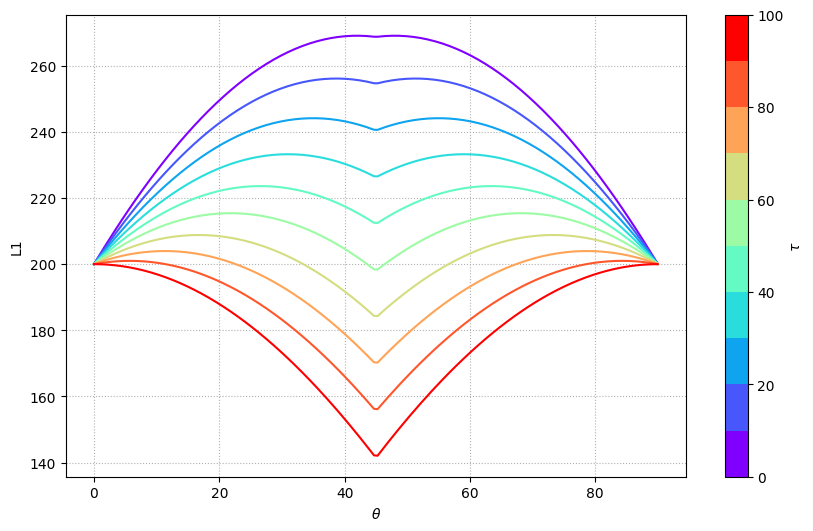

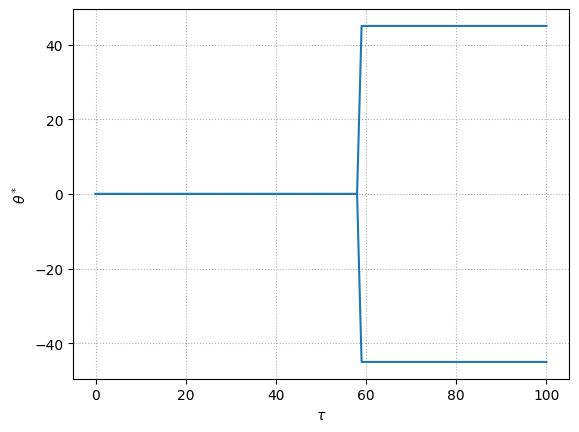

In [14]:
import numpy as np
import matplotlib as mpl 
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import cm, colors

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Let's confirm the rotations are right
T = 100

all_L1s = []
for i, tau in enumerate([10,20,30,40,50,60,70,80,90,100]):
    L1s, myL1s = [], []
    X = np.zeros((2,2*T))
    X[0,:T] = 1
    X[1,(T-tau):(2*T - tau)] = 1

    for i, theta in enumerate(np.arange(0, np.pi/2, 0.01)):
        R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

        X_r = R@X
        my_L1 = 2*(T-tau)*np.abs(np.cos(theta)) + \
                2*(T-tau)*np.abs(np.sin(theta)) + \
                tau*np.abs(np.cos(theta) - np.sin(theta)) + \
                tau*np.abs(np.cos(theta) + np.sin(theta))
        
        L1s.append(np.abs(X_r).sum())
        myL1s.append(my_L1)

    all_L1s.append(np.array(L1s))
  
# color = cm.rainbow(np.linspace(0, 1, 10))

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
cmap = plt.get_cmap('rainbow', 10)
norm = colors.Normalize(0, T)

for i in range(10):
    ax.plot(np.arange(0, np.pi/2, 0.01)*(180/np.pi), all_L1s[i], c=cmap(i))

fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=fr"$\tau$")

plt.ylabel("L1"), plt.xlabel(fr"$\theta$")
plt.grid(ls=":")
# plt.savefig("./L1_vs_theta.pdf")
plt.show()

theta = np.linspace(-np.pi/4, np.pi/4, num=501)
tau = np.arange(0,T+1,1)

L1s_all = []
opt_thetas = []

for t in tau:
    L1s = []
    X = np.zeros((2,2*T))
    X[0,:T] = 1
    X[1,(T-t):(2*T - t)] = 1

    for i, angle in enumerate(theta):
        R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
        X_r = R@X
        L1s.append(np.abs(X_r).sum())

    best_thetas = np.where(np.isclose(np.array(L1s), np.array(L1s).min()))
    # Going to need two lines to 
    if best_thetas[0].shape[0] == 1:
        best_thetas = (np.concatenate([best_thetas[0], best_thetas[0]]),)
    opt_thetas.append(best_thetas)
    

# Plot the optimal angle of rotation vs. overlap
plt.plot(tau, theta[np.concatenate(opt_thetas)[:,0]]*(180/np.pi), c="C0")
plt.plot(tau, theta[np.concatenate(opt_thetas)[:,1]]*(180/np.pi), c="C0")
plt.grid(ls=":")
plt.xlabel(fr"$\tau$")
plt.ylabel(fr"$\theta^*$")
# plt.savefig("./theta_vs_tau.pdf")
plt.show()
